In [252]:
# In any of your project files
from my_imports import *

## Merge and Compare All Models

In [254]:
# Load prediction CSVs
df_lstm = pd.read_csv('var/predictions/2024_lstm_and_recot.csv', parse_dates=['timestamp'])
df_transformer = pd.read_csv('var/predictions/2024_transformer_predictions.csv', parse_dates=['timestamp'])
df_lr = pd.read_csv('var/predictions/linear_regression_predictions_2024_updated_2.csv', parse_dates=['timestamp'])


In [255]:
print("Original DataFrame with N/A values:")
print(df_transformer)
print("\nMissing values before interpolation:")
print(df_transformer.isnull().sum())
print("\nDataFrame dtypes:")
print(df_transformer.dtypes)

Original DataFrame with N/A values:
               timestamp  predicted_demand_2024
0    2024-01-02 00:00:00           46954.515162
1    2024-01-02 01:00:00           45608.053456
2    2024-01-02 02:00:00           45226.692606
3    2024-01-02 03:00:00           45040.873195
4    2024-01-02 04:00:00           45384.223650
...                  ...                    ...
8754 2024-12-31 19:00:00           48687.194038
8755 2024-12-31 20:00:00           48529.557548
8756 2024-12-31 21:00:00           47605.471083
8757 2024-12-31 22:00:00           46464.354647
8758 2024-12-31 23:00:00           45372.639887

[8759 rows x 2 columns]

Missing values before interpolation:
timestamp                0
predicted_demand_2024    0
dtype: int64

DataFrame dtypes:
timestamp                datetime64[ns]
predicted_demand_2024           float64
dtype: object


In [256]:
# Rename columns for clarity
df_transformer.rename(columns={'predicted_demand_2024': 'transformer_pred'}, inplace=True)

In [257]:
df_transformer

,timestamp,transformer_pred
0,2024-01-02 00:00:00,46954.515162
1,2024-01-02 01:00:00,45608.053456
2,2024-01-02 02:00:00,45226.692606
3,2024-01-02 03:00:00,45040.873195
4,2024-01-02 04:00:00,45384.223650
...,...,...
8754,2024-12-31 19:00:00,48687.194038
8755,2024-12-31 20:00:00,48529.557548
8756,2024-12-31 21:00:00,47605.471083
8757,2024-12-31 22:00:00,46464.354647


In [258]:
df_lstm.head()

,timestamp,LSTM_pred,ERCOT
0,2024-01-01 00:00:00,40368.589756,41621.968883
1,2024-01-01 01:00:00,39779.581060,41223.480177
2,2024-01-01 02:00:00,40237.337998,41479.399746
3,2024-01-01 03:00:00,40268.373052,41472.770126
4,2024-01-01 04:00:00,40293.981807,41477.440791


In [259]:
# Merge all on timestamp
merged_df = df_lstm.merge(df_transformer, on='timestamp', how='inner')
merged_df = merged_df.merge(df_lr, on='timestamp', how='inner')

In [260]:
# Drop rows with missing values
merged_df.dropna(inplace=True)

In [261]:
merged_df

,timestamp,LSTM_pred,ERCOT,transformer_pred,linear_regression_pred
0,2024-01-02 00:00:00,48899.027563,46594.649950,46954.515162,40996.696672
1,2024-01-02 01:00:00,47634.333484,45765.055235,45608.053456,40619.679310
2,2024-01-02 02:00:00,47043.341762,45357.843684,45226.692606,40494.070029
3,2024-01-02 03:00:00,47032.087704,45341.963319,45040.873195,40891.966954
4,2024-01-02 04:00:00,47333.466468,45572.238632,45384.223650,40244.521635
...,...,...,...,...,...
8754,2024-12-31 19:00:00,51237.284964,48175.877538,48687.194038,52937.003729
8755,2024-12-31 20:00:00,50410.524181,47619.264355,48529.557548,50326.885979
8756,2024-12-31 21:00:00,49026.897074,46737.678611,47605.471083,47635.318413
8757,2024-12-31 22:00:00,47547.313424,45775.649767,46464.354647,48675.306763


In [262]:
# Save merged data to a new CSV file
merged_df.to_csv('merged_all_predictions_2024.csv', index=False)

In [263]:
merged_df

,timestamp,LSTM_pred,ERCOT,transformer_pred,linear_regression_pred
0,2024-01-02 00:00:00,48899.027563,46594.649950,46954.515162,40996.696672
1,2024-01-02 01:00:00,47634.333484,45765.055235,45608.053456,40619.679310
2,2024-01-02 02:00:00,47043.341762,45357.843684,45226.692606,40494.070029
3,2024-01-02 03:00:00,47032.087704,45341.963319,45040.873195,40891.966954
4,2024-01-02 04:00:00,47333.466468,45572.238632,45384.223650,40244.521635
...,...,...,...,...,...
8754,2024-12-31 19:00:00,51237.284964,48175.877538,48687.194038,52937.003729
8755,2024-12-31 20:00:00,50410.524181,47619.264355,48529.557548,50326.885979
8756,2024-12-31 21:00:00,49026.897074,46737.678611,47605.471083,47635.318413
8757,2024-12-31 22:00:00,47547.313424,45775.649767,46464.354647,48675.306763


In [264]:
# Define evaluation function
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    accuracy = 100 - mape
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "Final Accuracy (%)": accuracy
    }


In [265]:
# Evaluate all models
metrics_lstm = evaluate_model(merged_df['ERCOT'], merged_df['LSTM_pred'])
metrics_trans = evaluate_model(merged_df['ERCOT'], merged_df['transformer_pred'])
metrics_lr = evaluate_model(merged_df['ERCOT'], merged_df['linear_regression_pred'])

In [266]:
# Display results
print("\n🔹 LSTM:", metrics_lstm)
print("🔹 Transformer:", metrics_trans)
print("🔹 Linear Regression:", metrics_lr)


🔹 LSTM: {'MAE': 3241.9898898746255, 'RMSE': 4540.270656636354, 'MAPE (%)': 5.730810049374642, 'Final Accuracy (%)': 94.26918995062536}
🔹 Transformer: {'MAE': 756.352750195812, 'RMSE': 992.4164116784393, 'MAPE (%)': 1.4138386884957903, 'Final Accuracy (%)': 98.58616131150421}
🔹 Linear Regression: {'MAE': 5825.503606788528, 'RMSE': 7537.962985649983, 'MAPE (%)': 11.240785920416808, 'Final Accuracy (%)': 88.75921407958319}


In [267]:
# Display results neatly
print("\n Evaluation Results for 2024 ERCOT Forecasting:\n")
print("LSTM Model:")
print(f"   ➤ MAE               : {metrics_lstm['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_lstm['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_lstm['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_lstm['Final Accuracy (%)']:.2f}%\n")

print("Transformer Model:")
print(f"   ➤ MAE               : {metrics_trans['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_trans['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_trans['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_trans['Final Accuracy (%)']:.2f}%\n")

print("Linear Regression Model:")
print(f"   ➤ MAE               : {metrics_lr['MAE']:.2f}")
print(f"   ➤ RMSE              : {metrics_lr['RMSE']:.2f}")
print(f"   ➤ MAPE (%)          : {metrics_lr['MAPE (%)']:.2f}%")
print(f"   ➤ Final Accuracy (%) : {metrics_lr['Final Accuracy (%)']:.2f}%")



 Evaluation Results for 2024 ERCOT Forecasting:

LSTM Model:
   ➤ MAE               : 3241.99
   ➤ RMSE              : 4540.27
   ➤ MAPE (%)          : 5.73%
   ➤ Final Accuracy (%) : 94.27%

Transformer Model:
   ➤ MAE               : 756.35
   ➤ RMSE              : 992.42
   ➤ MAPE (%)          : 1.41%
   ➤ Final Accuracy (%) : 98.59%

Linear Regression Model:
   ➤ MAE               : 5825.50
   ➤ RMSE              : 7537.96
   ➤ MAPE (%)          : 11.24%
   ➤ Final Accuracy (%) : 88.76%


In [268]:
# Save merged comparison file (optional)
merged_df.to_csv('var/predictions/final_all_3_model_predictions_2024_data.csv', index=False)

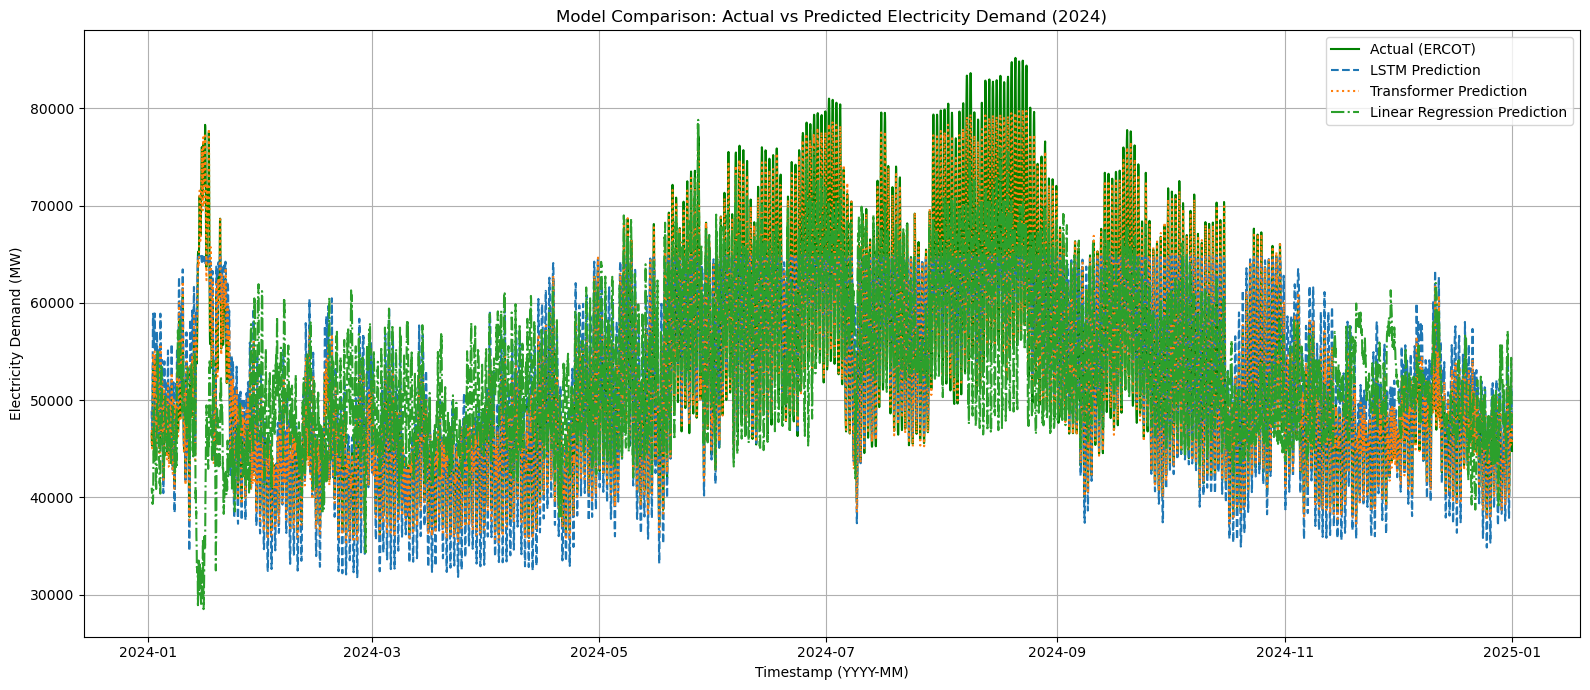

In [269]:
# Plot comparison
plt.figure(figsize=(16, 7))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual (ERCOT)', color='green')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM Prediction', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer Prediction', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression Prediction', linestyle='-.')
plt.title('Model Comparison: Actual vs Predicted Electricity Demand (2024)')
plt.xlabel('Timestamp (YYYY-MM)')
plt.ylabel('Electricity Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the image
plt.savefig('plots/model_comparison_2024.png', dpi=300)
plt.show()


In [270]:
import matplotlib.pyplot as plt
# Make sure you have this import:
from datetime import datetime

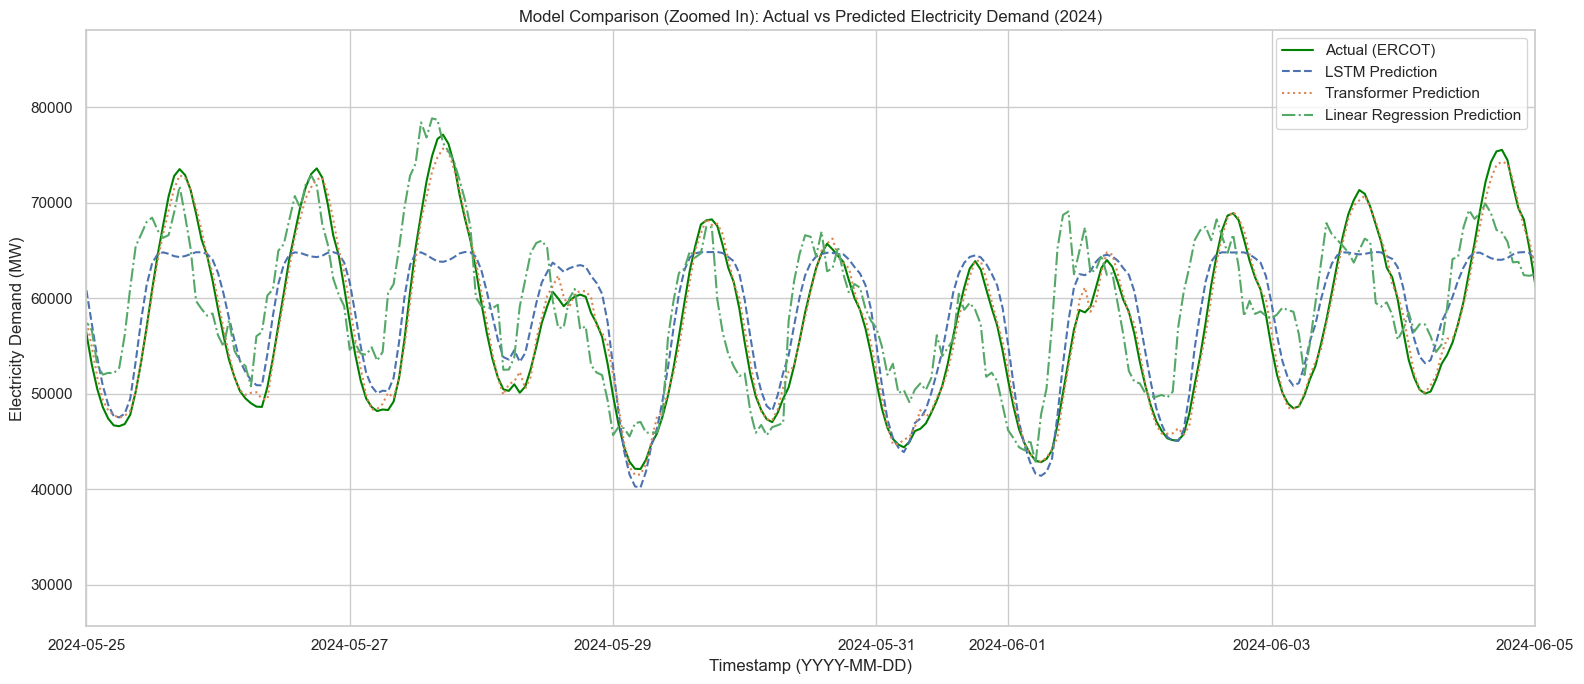

In [311]:


# Plot comparison
plt.figure(figsize=(16, 7))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual (ERCOT)', color='green')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM Prediction', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer Prediction', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression Prediction', linestyle='-.')
plt.title('Model Comparison (Zoomed In): Actual vs Predicted Electricity Demand (2024)')
plt.xlabel('Timestamp (YYYY-MM-DD)')
plt.ylabel('Electricity Demand (MW)')
plt.xlim(datetime(2024,5,25), datetime(2024,6,5))
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the image
plt.savefig('plots/model_comparison_2024_sample_data.png', dpi=300)
plt.show()

## Evaluation for Year, Month, Day


In [273]:
# Helper to calculate metrics
def compute_metrics(y_true, y_pred):
    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    accuracy = 100 - mape
    return round(mape, 1), round(rmse_val, 1), round(accuracy, 1)

In [274]:
# Select Year (2024), Month (e.g. July), and Day (e.g. July 15)
year_df = merged_df.copy()
month_df = merged_df[merged_df['timestamp'].dt.month == 7]
day_df = merged_df[merged_df['timestamp'].dt.date == pd.to_datetime('2024-07-15').date()]

In [275]:
# Models and horizons
results = []

for label, df in zip(['Year (2024)', 'Month', 'Day'], [year_df, month_df, day_df]):
    # LSTM
    mape, rmse, acc = compute_metrics(df['ERCOT'], df['LSTM_pred'])
    results.append(['LSTM', label, mape, rmse, acc])
    # Transformer
    mape, rmse, acc = compute_metrics(df['ERCOT'], df['transformer_pred'])
    results.append(['Transformer', label, mape, rmse, acc])
    # Linear Regression
    mape, rmse, acc = compute_metrics(df['ERCOT'], df['linear_regression_pred'])
    results.append(['Linear Regression', label, mape, rmse, acc])

In [276]:
# Convert to DataFrame for pretty output
table_df = pd.DataFrame(results, columns=['Model', 'Horizon', 'MAE (%)', 'RMSE (MW)', 'Acc. (%)'])

In [277]:
# # Show table without ace_tools
# print("\n Model Forecasting Metrics by Horizon\n")
# print(table_df.to_string(index=False))


In [278]:
table_df

,Model,Horizon,MAE (%),RMSE (MW),Acc. (%)
0,LSTM,Year (2024),5.7,4540.3,94.3
1,Transformer,Year (2024),1.4,992.4,98.6
2,Linear Regression,Year (2024),11.2,7538.0,88.8
3,LSTM,Month,6.6,5695.9,93.4
4,Transformer,Month,1.2,926.6,98.8
5,Linear Regression,Month,10.1,7046.6,89.9
6,LSTM,Day,9.7,8115.5,90.3
7,Transformer,Day,1.6,1233.7,98.4
8,Linear Regression,Day,9.8,7428.0,90.2


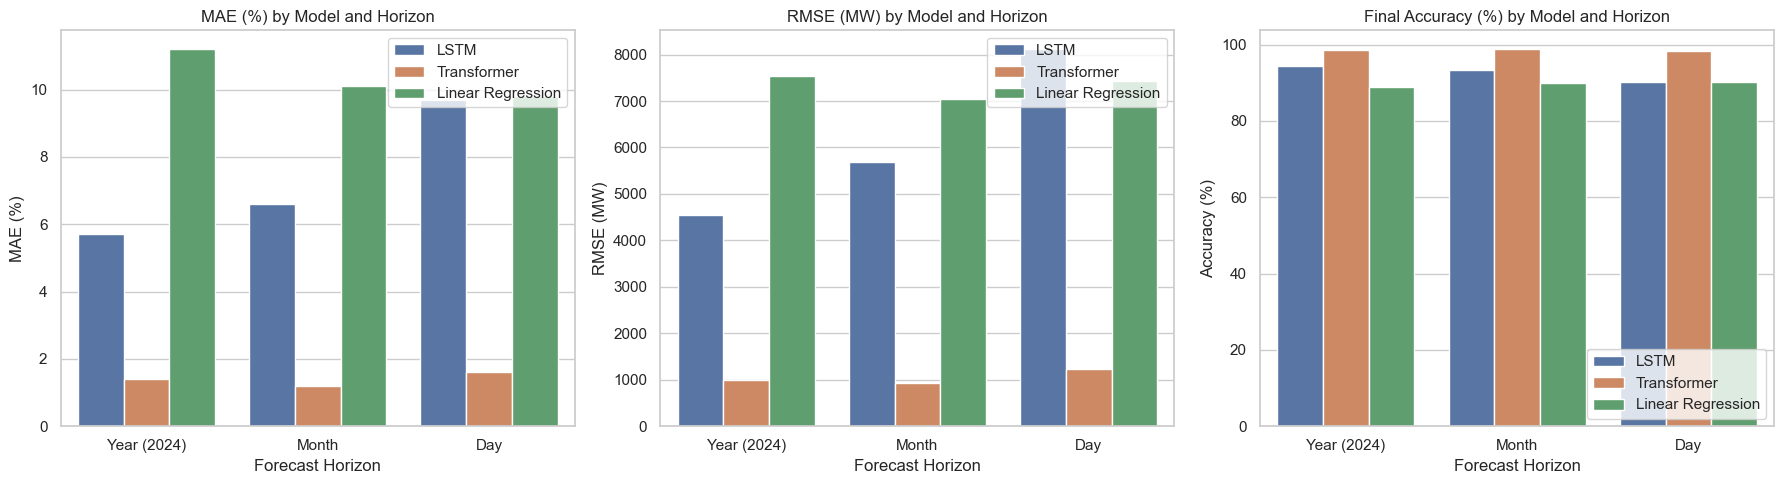

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure seaborn style is used
sns.set(style="whitegrid")

# Set plot size
plt.figure(figsize=(18, 5))

# Subplot 1: MAE (%)
plt.subplot(1, 3, 1)
sns.barplot(data=table_df, x='Horizon', y='MAE (%)', hue='Model')
plt.title('MAE (%) by Model and Horizon')
plt.ylabel('MAE (%)')
plt.xlabel('Forecast Horizon')
plt.legend(loc='upper right')

# Subplot 2: RMSE (MW)
plt.subplot(1, 3, 2)
sns.barplot(data=table_df, x='Horizon', y='RMSE (MW)', hue='Model')
plt.title('RMSE (MW) by Model and Horizon')
plt.ylabel('RMSE (MW)')
plt.xlabel('Forecast Horizon')
plt.legend(loc='upper right')

# Subplot 3: Final Accuracy (%)
plt.subplot(1, 3, 3)
sns.barplot(data=table_df, x='Horizon', y='Acc. (%)', hue='Model')
plt.title('Final Accuracy (%) by Model and Horizon')
plt.ylabel('Accuracy (%)')
plt.xlabel('Forecast Horizon')
plt.legend(loc='lower right')

# Save the image
plt.savefig('plots/Final Accuracy by Model and Horizon.png', dpi=300)

# Adjust layout and show
plt.tight_layout()
plt.show()


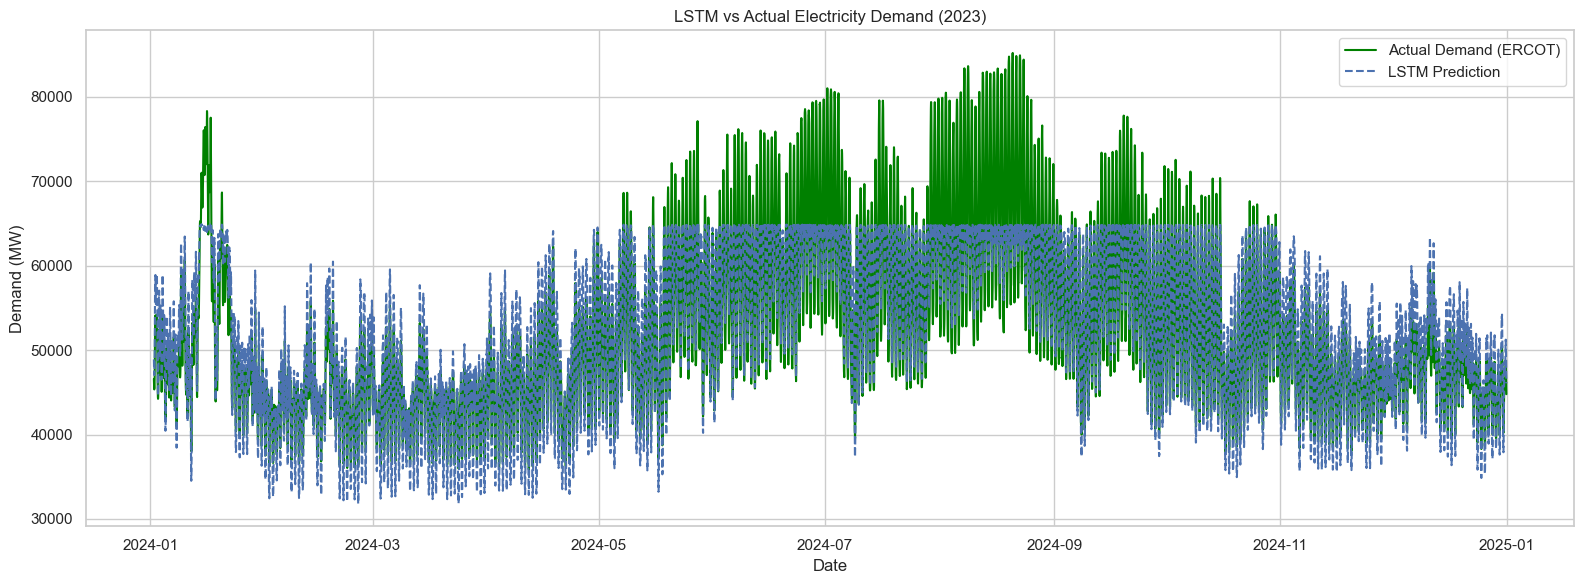

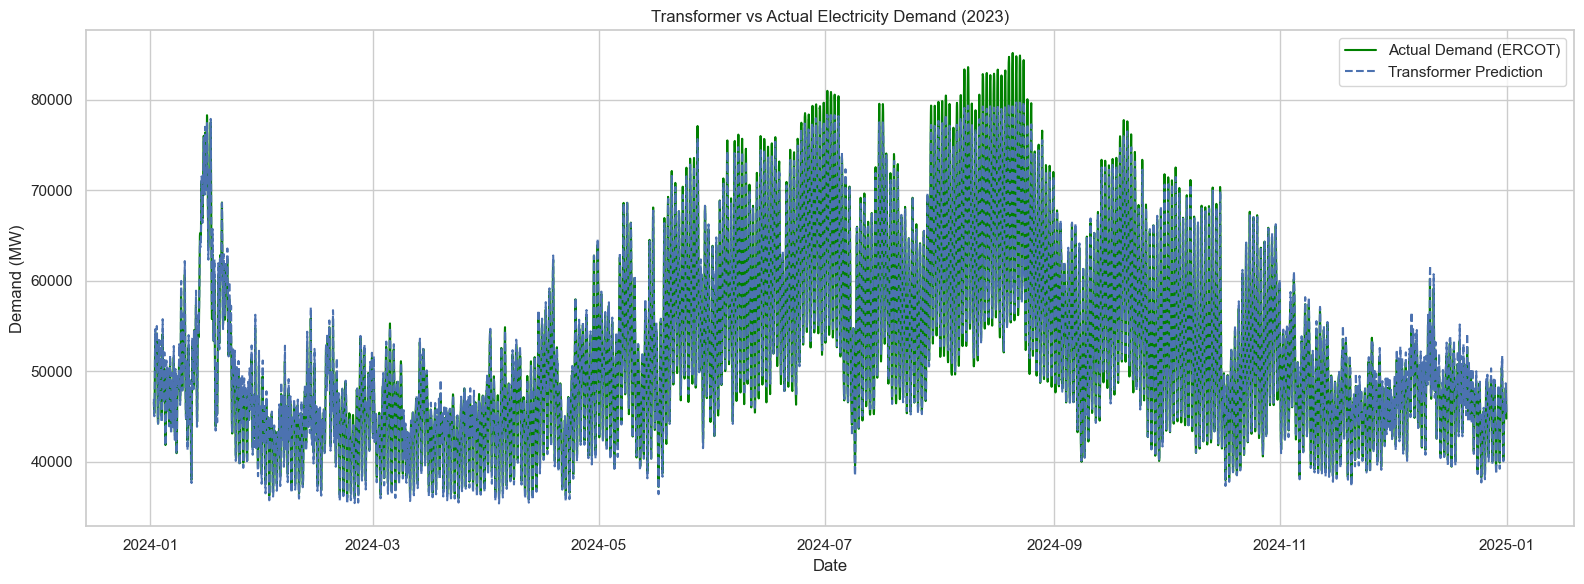

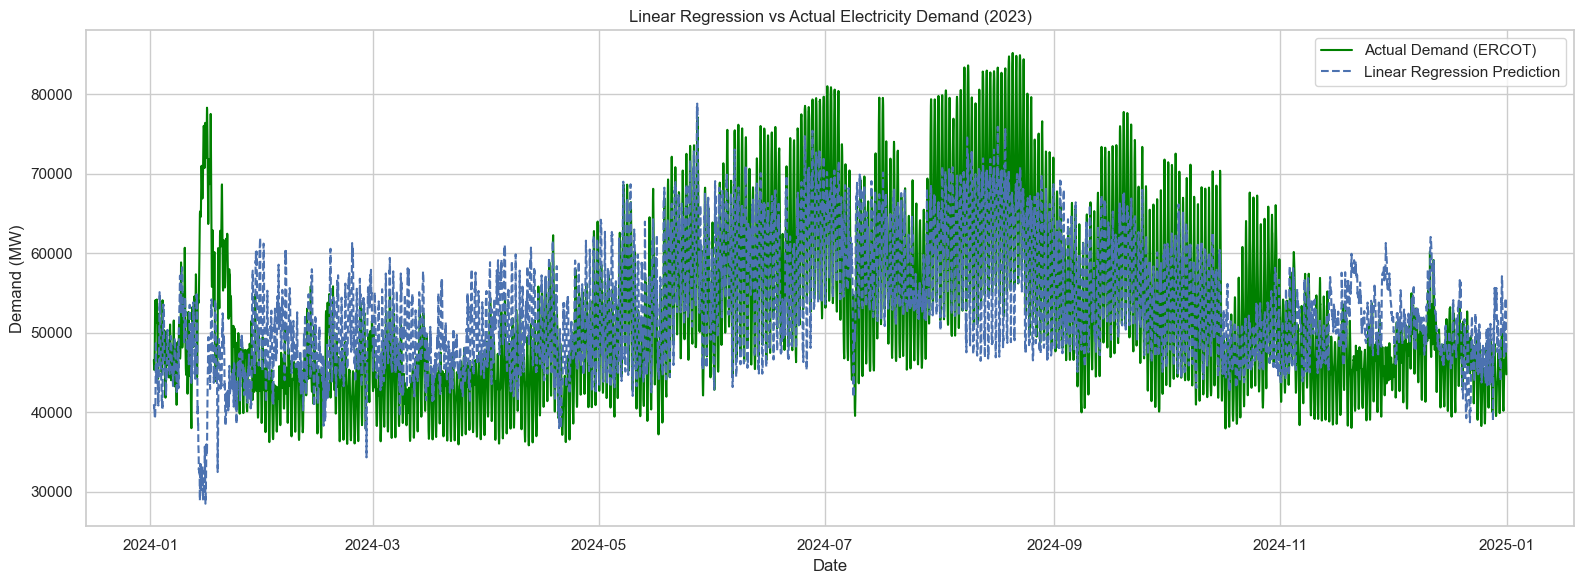

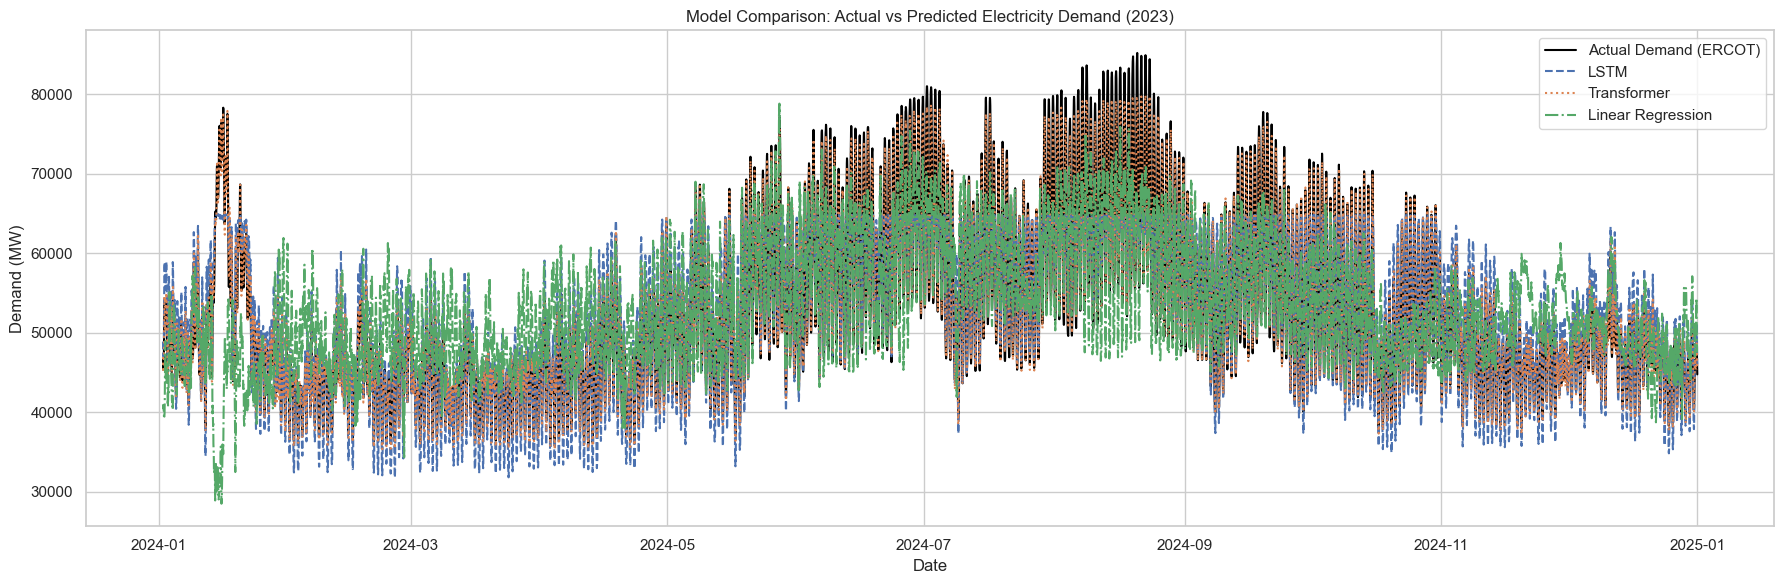

In [280]:
import matplotlib.pyplot as plt

# Function to create individual plots
def plot_model_vs_actual(df, model_col, model_name):
    plt.figure(figsize=(16, 6))
    plt.plot(df['timestamp'], df['ERCOT'], label='Actual Demand (ERCOT)', color='green')
    plt.plot(df['timestamp'], df[model_col], label=f'{model_name} Prediction', linestyle='--')
    plt.title(f'{model_name} vs Actual Electricity Demand (2023)')
    plt.xlabel('Date')
    plt.ylabel('Demand (MW)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot each model separately
plot_model_vs_actual(merged_df, 'LSTM_pred', 'LSTM')
plot_model_vs_actual(merged_df, 'transformer_pred', 'Transformer')
plot_model_vs_actual(merged_df, 'linear_regression_pred', 'Linear Regression')

# Combined comparison plot
plt.figure(figsize=(18, 6))
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual Demand (ERCOT)', color='black')
plt.plot(merged_df['timestamp'], merged_df['LSTM_pred'], label='LSTM', linestyle='--')
plt.plot(merged_df['timestamp'], merged_df['transformer_pred'], label='Transformer', linestyle=':')
plt.plot(merged_df['timestamp'], merged_df['linear_regression_pred'], label='Linear Regression', linestyle='-.')
plt.title('Model Comparison: Actual vs Predicted Electricity Demand (2023)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\sajib\AppData\Local\Temp\ipykernel_30320\616348504.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start='2024-01-01', periods=365*24, freq='H') # Hourly data for a year


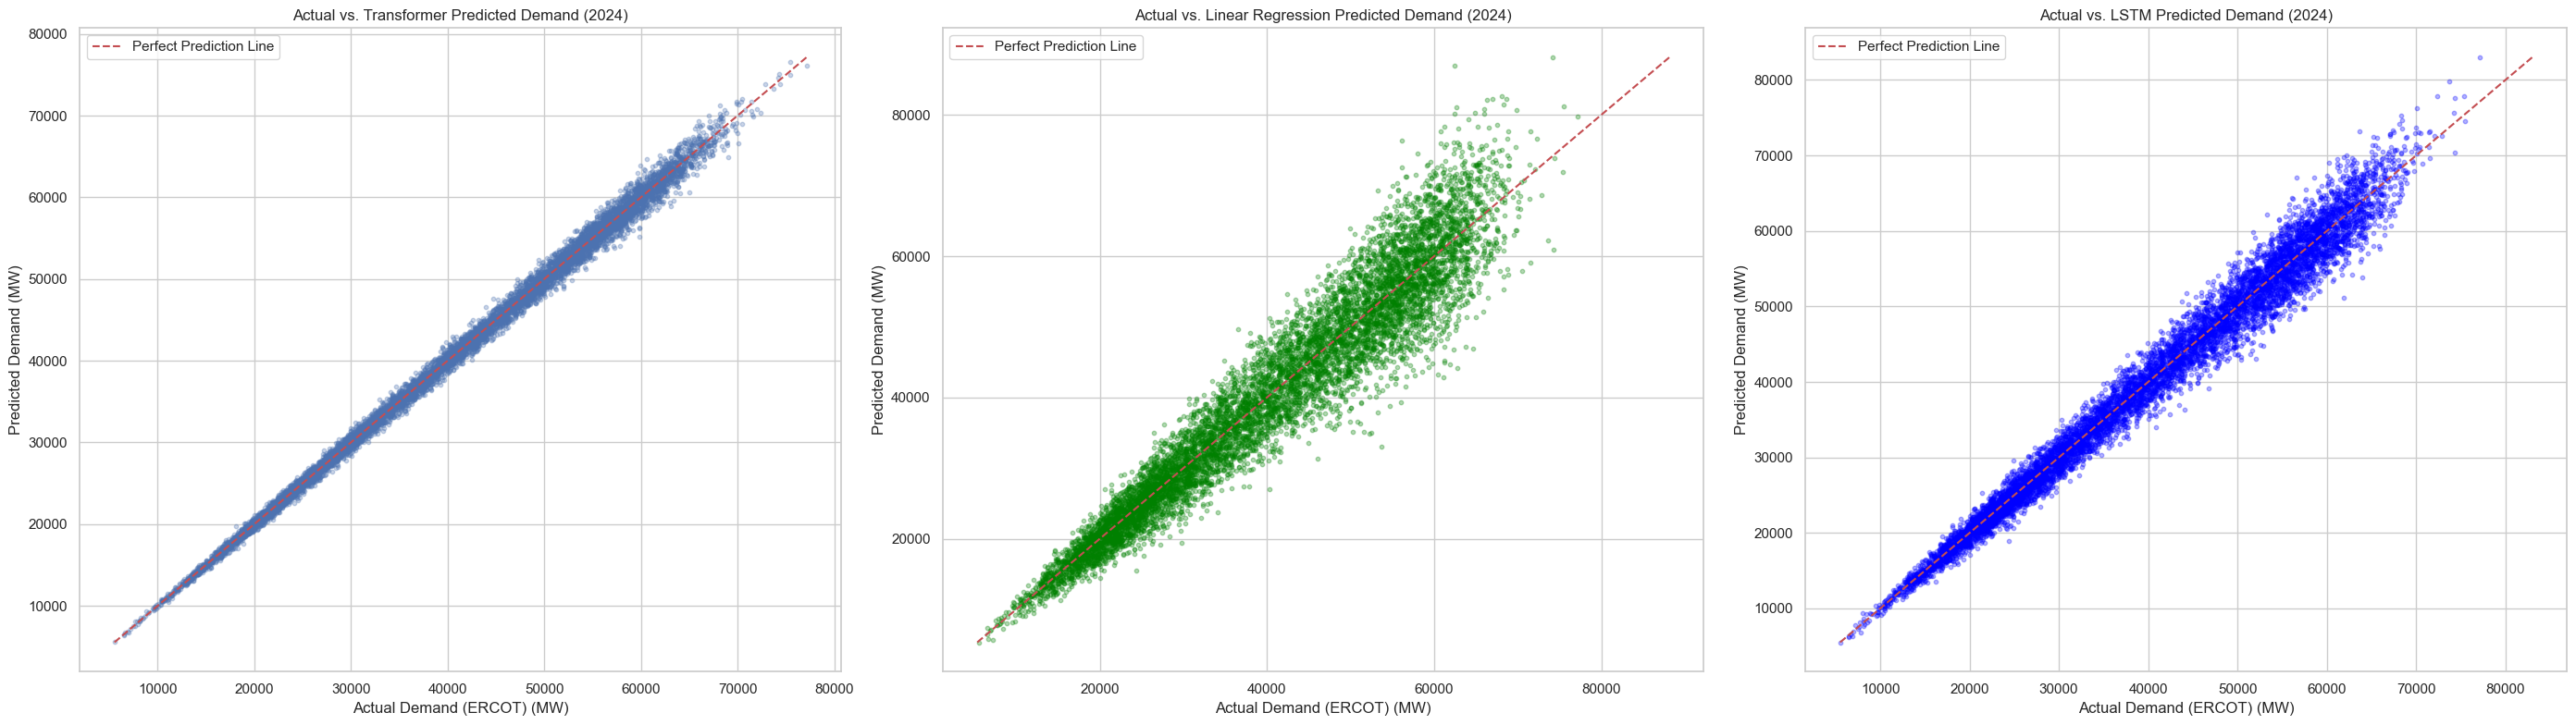

In [281]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Assumed DataFrame structure ---
# For demonstration purposes, let's create a sample df_comparison DataFrame.
# In your actual environment, this DataFrame should already be loaded
# with your real 'ERCOT', 'predicted_demand_2024',
# 'predicted_demand_linear_regression_2024', and
# 'predicted_demand_lstm_2024' data.
np.random.seed(42) # for reproducibility
dates = pd.date_range(start='2024-01-01', periods=365*24, freq='H') # Hourly data for a year
actual_demand = 40000 + 20000 * np.sin(np.linspace(0, 2 * np.pi, len(dates))) + np.random.normal(0, 5000, len(dates))

# Transformer predictions (assumed highest accuracy)
transformer_pred = actual_demand * (1 + np.random.normal(0, 0.02, len(dates)))

# Linear Regression predictions (assumed lower accuracy, more noise)
linear_reg_pred = actual_demand * (1 + np.random.normal(0, 0.1, len(dates)))

# LSTM predictions (assumed better than Linear Regression but not as good as Transformer)
lstm_pred = actual_demand * (1 + np.random.normal(0, 0.05, len(dates)))

df_comparison = pd.DataFrame({
    'ERCOT': actual_demand,
    'predicted_demand_2024': transformer_pred,
    'predicted_demand_linear_regression_2024': linear_reg_pred,
    'predicted_demand_lstm_2024': lstm_pred
}, index=dates)
# --- End of sample DataFrame creation ---


# Create a figure with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(28, 8)) # Increased figure width for three plots

# --- Plot for Transformer Model ---
axes[0].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_2024'], alpha=0.3, s=10)

# Get min/max for the 45-degree line for Transformer plot
min_val_trans = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_2024'].min())
max_val_trans = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_2024'].max())
axes[0].plot([min_val_trans, max_val_trans],
             [min_val_trans, max_val_trans],
             '--r', label='Perfect Prediction Line') # 45-degree line

axes[0].set_title('Actual vs. Transformer Predicted Demand (2024)')
axes[0].set_xlabel('Actual Demand (ERCOT) (MW)')
axes[0].set_ylabel('Predicted Demand (MW)')
axes[0].grid(True)
axes[0].legend()

# --- Plot for Linear Regression Model ---
axes[1].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_linear_regression_2024'], alpha=0.3, s=10, color='green')

# Get min/max for the 45-degree line for Linear Regression plot
min_val_lr = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_linear_regression_2024'].min())
max_val_lr = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_linear_regression_2024'].max())
axes[1].plot([min_val_lr, max_val_lr],
             [min_val_lr, max_val_lr],
             '--r', label='Perfect Prediction Line') # 45-degree line

axes[1].set_title('Actual vs. Linear Regression Predicted Demand (2024)')
axes[1].set_xlabel('Actual Demand (ERCOT) (MW)')
axes[1].set_ylabel('Predicted Demand (MW)') # Keep consistent y-label for comparison
axes[1].grid(True)
axes[1].legend()


# --- Plot for LSTM Model ---
axes[2].scatter(df_comparison['ERCOT'], df_comparison['predicted_demand_lstm_2024'], alpha=0.3, s=10, color='blue')

# Get min/max for the 45-degree line for LSTM plot
min_val_lstm = min(df_comparison['ERCOT'].min(), df_comparison['predicted_demand_lstm_2024'].min())
max_val_lstm = max(df_comparison['ERCOT'].max(), df_comparison['predicted_demand_lstm_2024'].max())
axes[2].plot([min_val_lstm, max_val_lstm],
             [min_val_lstm, max_val_lstm],
             '--r', label='Perfect Prediction Line') # 45-degree line

axes[2].set_title('Actual vs. LSTM Predicted Demand (2024)')
axes[2].set_xlabel('Actual Demand (ERCOT) (MW)')
axes[2].set_ylabel('Predicted Demand (MW)')
axes[2].grid(True)
axes[2].legend()

# Adjust layout to prevent overlapping titles/labels
# Save the plot as PNG (higher quality)
plt.savefig('predicted_demand_line.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()
